### Automatic cycling route generator
adapted from the article](https://medium.com/p/16a266d468a5/edit) and from OSMmx documentation (espexialy the osmnx-examples/notebooks
/12-node-elevations-edge-grades.ipynb in (https://github.com/gboeing/osmnx-examples/tree/main/notebooks)

voir aussi  https://towardsdatascience.com/planning-the-perfect-hike-with-networkx-and-openstreetmap-2fbeaded3cc6  et https://heidimhurst.github.io/assets/networks/coursework.html


## Install all non built-in packages
#### ... and import them

In [ ]:
###############################################################################
# Script Name: optimizing_road.ipynb
# Description: This script aim to help biker, runners, trailers, .. to create their own road based on several criteria (Strava popularity, grade, ..)
# Author: Daniel COMPARAT
# Date: 2014-05-26
###############################################################################

# Not need to run it if we are in the proper environment 

 '''
%pip install pygeos
%pip install geopandas
%pip install --pre osmnx # to prepare for version 2.0.0 if not should be %pip install osmnx
%pip install folium
%pip install SRTM.py
%pip install matplotlib
'''

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import folium
import networkx as nx
import srtm
import time
import matplotlib.pyplot as plt
import collections
import multiprocessing as mp
import matplotlib.colors as mcolors
import graph_utils
import importlib

from graph_utils import *  # our functions


# Choose the area to work with

## show it on Open Street Map

gps coord limits: [48.6410789 48.8389241] [2.0400006 2.340004]


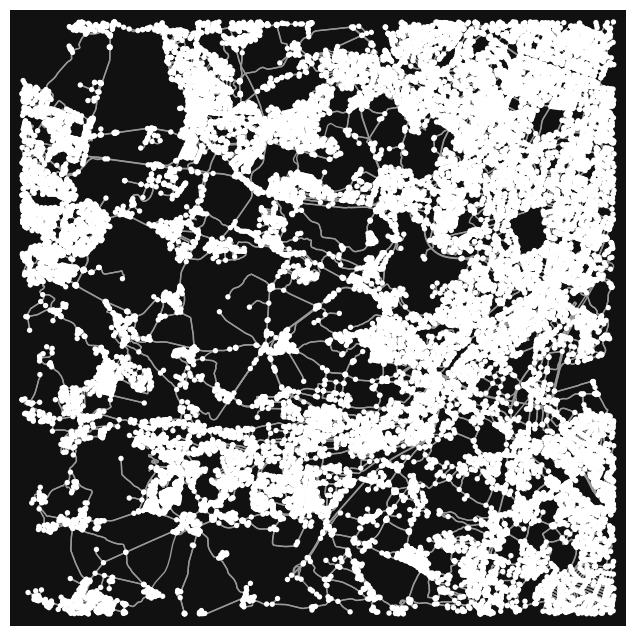

In [3]:
# Option A : Download GPS datas for an area
# place_name = "Orsay, France"
# G = ox.graph_from_place(place_name, network_type='bike')              # load a given graph and show it

# Option B : Download GPS datas from this spot + a certain dis
our_spot = (48.826182325328624, 2.3599337881881812)                                                    # our spot ! (latitude between -90 et 90, longitude between -180 et 180)
our_spot = (48.78, 2.26) # ~Plessis Robinson 
our_spot = (48.74, 2.19) # ~ Saclay
# print(ox.geocode_to_gdf(f"{our_spot[0]}, {our_spot[1]}")) # Show information
sqr_dist = 11  # kms                                                                                                    # takes 4 minutes to download for 30 Kms square
G = ox.graph_from_point(our_spot, dist=sqr_dist*1000, network_type='drive')   

ox.io.save_graphml(G, filepath='map_near_home_10k_drive.graphml', gephi=False, encoding='utf-8')    # save graph as map.graphml for later if needed


# Option C : Load an already saved GPS datas
# G = ox.io.load_graphml('graph_with_popularity.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)


gdf_nodes, gdf_edges = ox.graph_to_gdfs(G, nodes=True, edges=True)                                                      # Go with GeoPandas GeoDataFrames
gps_x_min, gps_x_max = min(gdf_nodes['x'])+0.000001, max(gdf_nodes['x'])-0.000001
gps_y_min, gps_y_max = min(gdf_nodes['y'])+0.000001, max(gdf_nodes['y'])-0.000001
print(f'gps coord limits: [{gps_y_min} {gps_y_max}] [{gps_x_min} {gps_x_max}]')


# To view it on Open STreet Map (but take a lot of Memory and time)
# ox.graph_to_gdfs(G, nodes=False).explore()
fig, ax = ox.plot_graph(G)


# Test to be improved to show area of interest (tags) such as water, ..

See (https://wiki.openstreetmap.org/wiki/Tags) 

may be use osmnx.geocoder module (cf notebook 11)

In [ ]:
# Define the tags for the features you are interested in
tags = {
    "drinking_water": "yes",
    "amenity": ["car_wash", "bicycle_repair_station"],
    "highway": ["cycleway", "path"],
}


# Initialize a dictionary to store the features
features = {}

# Try to fetch the features using the tags
try:
    features = ox.features_from_place(place_name, tags=tags)
    if features.empty:
        print("No data found for the specified tags and location.")
    else:
        # Proceed with further processing if data is found
        print("Data found, proceeding with further processing.")
except Exception as e:
    print(f"An error occurred: {e}")
    

# tiles = "cartodbdarkmatter"
tiles= "cartodbpositron"
# tiles="OpenStreetMap"

# Create a folium map centered around the graph
centroid = features.geometry.unary_union.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=14, tiles=tiles)

# Define colors and icons for different types of features
feature_colors = {
    "drinking_water": "blue",
    "car_wash": "red",
    "bicycle_repair_station": "orange",
    "cycleway": "purple",
    "path": "brown"
}

feature_icons = {
    "drinking_water": "tint",
    "car_wash": "car",
    "bicycle_repair_station": "wrench",
    "path": "road"
}

# Add the features to the map with different colors and icons
for idx, row in features.iterrows():
    feature_type = row['amenity'] if 'amenity' in row else row['highway'] if 'highway' in row else None
    color = feature_colors.get(feature_type, "gray")
    icon = feature_icons.get(feature_type, "info-sign")

    if row.geometry.geom_type == "Point":
        folium.Marker(
            location=(row.geometry.y, row.geometry.x),
            icon=folium.Icon(color=color, icon=icon, prefix='fa')
        ).add_to(m)
    elif row.geometry.geom_type == "LineString":
        folium.PolyLine(
            [(pt[1], pt[0]) for pt in row.geometry.coords],
            color=color,
            weight=2
        ).add_to(m)

# Display the map
m


Data found, proceeding with further processing.


# Calculate and Plot the attributes: speed, travel time, elevation, grade

In [4]:

from keys import google_elevation_api_key
add_node_elevations(G, google_elevation_api_key)  # Add elevation data using Google API if available, otherwise use SRTM

# Add edge grades speeds and travel times
G = ox.elevation.add_edge_grades(G)     # Calculate edge grades and add it to edge
G = ox.add_edge_speeds(G)               # impute speed on all edges missing data
G = ox.add_edge_travel_times(G)         # calculate travel time (seconds) for all edges

nodes, edges = ox.graph_to_gdfs(G)    # Go with GeoPandas GeoDataFrames


Elevation data added using Google Elevation API.


### Add attributes to edges (street_width, height_gain, ...).

In [5]:


street_widths = {
    "motorway": 4,
    "trunk": 3,
    "primary": 2.5,
    "secondary": 2,
    "tertiary": 1.5,
    "residential": 1,
    "service": 0.5,
    'unclassified': 0.5
}

def get_street_width(d, default_width=1):
    highway = d.get('highway')
    if isinstance(highway, list):  # In case 'highway' is a list, take the first element
        highway = highway[0]
    return street_widths.get(highway, default_width)


# Add street_width values to each edge in the graph
for _, _, _, data in G.edges(keys=True, data=True):
    data["street_width"] = get_street_width(data)
    

# Add height agin (d+ if >0 d- if <0) values to each edge in the graph
def add_height_gain_to_edges(G):
    for u, v, _, d in G.edges(keys=True, data=True):
        elevation_u = G.nodes[u].get('elevation', np.nan)
        elevation_v = G.nodes[v].get('elevation', np.nan)
        d['height_gain'] = float(elevation_v) - float(elevation_u)
    return G


G = add_height_gain_to_edges(G)


# ox.io.save_graphml(G, filepath='graph_with_all_attributes.graphml', gephi=False, encoding='utf-8') 

## Plot the nodes by elevation
Plot them colored from low (violet) to high (yellow).

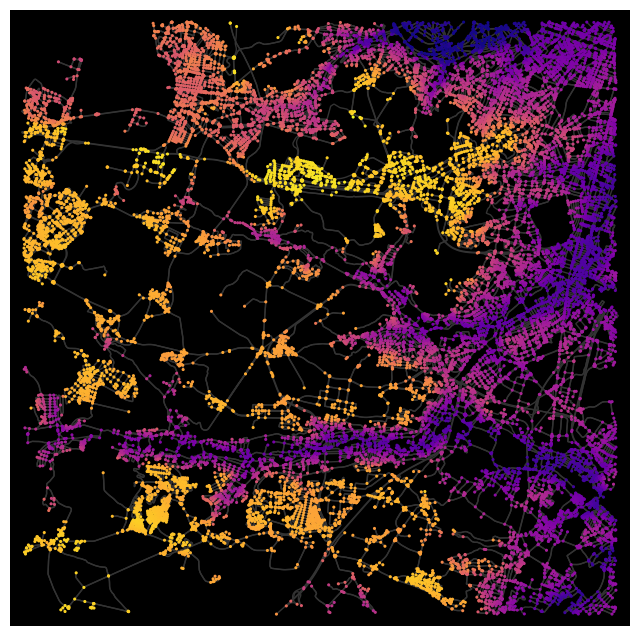

In [9]:
# get one color for each node, by elevation, then plot the network
nc = ox.plot.get_node_colors_by_attr(G, "elevation", cmap="plasma")
fig, ax = ox.plot_graph(G, node_color=nc, node_size=5, edge_color="#333333", bgcolor="k")

## Plot the edges by grade

Grade is the ratio of elevation change to edge length. Plot edges colored from low/flat (violet) to high/steep (yellow).

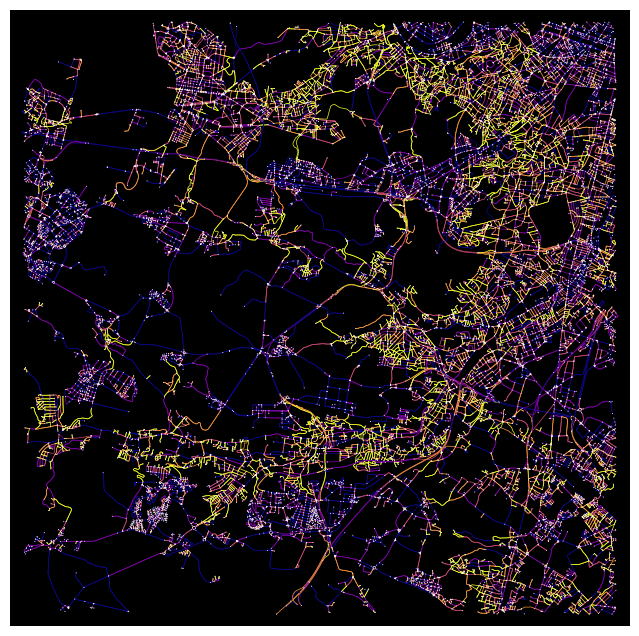

In [10]:
# get a color for each edge, by grade, then plot the network
ec = ox.plot.get_edge_colors_by_attr(G, "grade_abs", cmap="plasma", num_bins=5, equal_size=True)
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=0.5, node_size=0.5, bgcolor="k")

## Make a list of all slopes





In [104]:

# ==================================================
# Criteria for Defining a Climbing Road:
# ==================================================

# 1. Slope Threshold:
#    -------------------------------------------------
#    - Setting a minimum slope threshold (e.g., 1%): Ensure the road is consistently uphill, avoiding flat or downhill segments.

# 2. Boundary Conditions:
#    -------------------------------------------------
#    - Starting Point: The starting point should not be immediately adjacent to a lower (except if less than 1% slope) node, ensuring it is the beginning of the climb.
#    - Ending Point: The ending point should not connect to a higher (except if less than 1% slope) node, indicating the top of the climb.

# 3. Minimum Length:
#    -------------------------------------------------
#    - Length Requirement: Define a minimum length to ensure the climb is significant. This can be based on distance (100 m by default) and elevation (50 m by default).

# 4. Path Selection:
#    -------------------------------------------------
#    - Shortest Path: Consider the first few shortest paths (up to 5) between the same starting and ending points to capture different possible routes that meet the criteria without being exhaustive.
#    - Road Type: Differentiate between paved roads, trails, and other types of paths, as this might be relevant for specific applications. However, this differentiation is not done here.


import importlib
import graph_utils  # Import your module

# Reload the graph_utils module to ensure it's the most up-to-date version
importlib.reload(graph_utils)
from graph_utils import *


# Parameteres for the slope to be find
threshold_slope = 0.02
min_length=200
min_elevation_gain=60

# Identify Potential Starting Nodes
potential_start_nodes = [node for node in G.nodes if is_potential_start_node(G, node, threshold_slope)]

# Main extraction of the climbing paths
valid_climbs = []

for start_node in potential_start_nodes:
    climbing_paths = get_climbing_paths(G, start_node, threshold_slope)
    valid_climbing_paths = filter_paths(G, climbing_paths, min_length, min_elevation_gain)
    valid_climbs.extend(valid_climbing_paths)


c:\Users\Daniel\ownCloud\Code\python\gitlab\optimized-road\graph_utils.py:480: FutureWarning: The `get_route_edge_attributes` function has been deprecated and will be removed in the v2.0.0 release. Use the `routing.route_to_gdf` function instead. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  


## PLot the result on a map or on Open Street Map

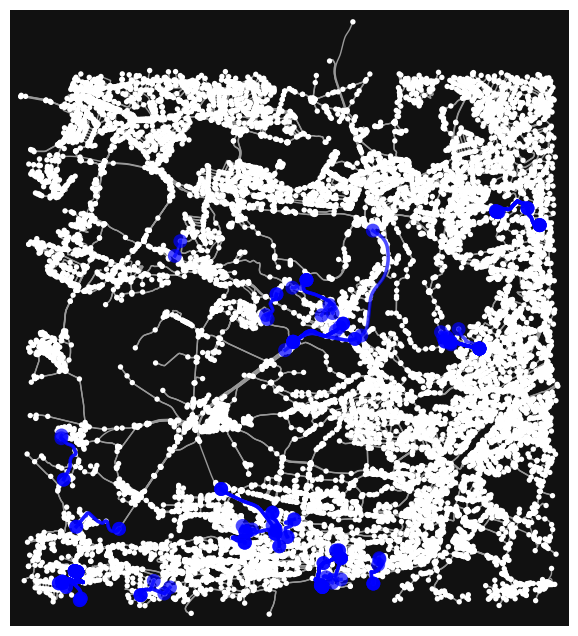

In [105]:
climbing_paths = [climb[0] for climb in valid_climbs]

# Create a list of linewidths for each route (all the same in this case)
route_linewidths = [2.5] * len(climbing_paths)

# Visualize the climbing paths using osmnx
fig, ax = ox.plot.plot_graph_routes(
    G, 
    climbing_paths, 
    route_colors='blue', 
    route_linewidths=route_linewidths, 
    route_alpha=0.7, 
    orig_dest_size=100
)

# Display the plot
plt.show()


# Show climbing roads with color depending on the slope on Open Strret Map
# climbing_paths = [climb[0] for climb in valid_climbs]
# map_with_climbs = display_paths_on_map(G, climbing_paths)
# map_with_climbs

### Save paths

In [ ]:

climbing_paths = [climb[0] for climb in valid_climbs]
gdf_paths_with_grades = convert_paths_to_gdf_with_grades(G, climbing_paths)

# Save to a GeoJSON file
save_paths_to_file(gdf_paths_with_grades, 'climbing_paths.geojson', 'geojson')

# Save to a Shapefile
# save_paths_to_file(gdf_paths_with_grades, 'climbing_paths.shp', 'shapefile')

# Save to a CSV file
# save_paths_to_file(gdf_paths_with_grades, 'climbing_paths.csv', 'csv')


## Import Strava HeatMap

Need cookies from account

In [10]:
# import importlib
import Strava_utils  # Import your module

# If needed Reload the Strava_utils module to ensure it's the most up-to-date version
importlib.reload(Strava_utils)

# Call the get_strava_cookies function from the Strava_utils module and capture the returned values
key_pair_id, policy, signature = Strava_utils.get_strava_cookies()



Using existing Strava keys from keys.py


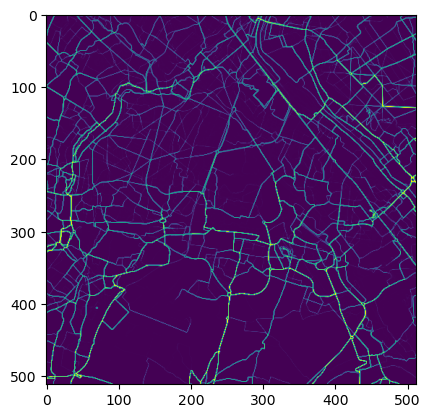

In [128]:
import matplotlib.pyplot as plt
import folium

importlib.reload(Strava_utils)
from Strava_utils import *


location=[48.76, 2.17] # FOr Saclay
location=[48.78, 2.25] # FOr Plessy Robinson
location=[48.82, 2.36] # Paris Maison


# Parameters for the Strava heatmap tile
activity = 'ride'  # Options: 'run', 'ride', 'winter', 'water', 'all'
color = 'blue'  # Options: 'blue', 'bluered', 'purple', 'hot', 'gray'
zoom_level = 11
nb_pixel = 512  # only 512 works; all other numbers give 256 pixels

# Convert the first coordinate of the route to tile coordinates
(xtile, ytile) = latlon_to_tile(location[0], location[1], zoom_level)

xtile = 1037
ytile = 706

# URL template for the Strava heatmap tile
tile_url = f'https://heatmap-external-a.strava.com/tiles-auth/{activity}/{color}/{zoom_level}/{xtile}/{ytile}.png?px={nb_pixel}&'

# Download a tile with authentication
tile_image = download_tile(tile_url, key_pair_id, policy, signature)

# Display the tile image
plt.imshow(tile_image)
plt.show()


### Save Strava HeatMap in .PNG or .dat file

In [51]:
from PIL import Image
import numpy as np
import io

output_dir = 'Strava_HeatMap_tiles'
os.makedirs(output_dir, exist_ok=True)
output_filename = f'{activity}_{color}_{zoom_level}_{xtile}_{ytile}_{nb_pixel}px.png'
output_path = os.path.join(output_dir, output_filename)


# Save the tile image PNG
image = Image.fromarray(tile_image.astype(np.uint8))
image.save(output_path)

# Save the tile image as a 512x512 matrix in a .dat file
matrix_output_path = os.path.join(output_dir, f'{activity}_{zoom_level}_{xtile}_{ytile}_{nb_pixel}px.dat')
tile_image.astype(np.uint8).tofile(matrix_output_path)

# Save the tile image as a 512x512 matrix of ASCII numbers
matrix_output_path = f'{output_dir}/{activity}_{zoom_level}_{xtile}_{ytile}_{nb_pixel}px.dat'
np.savetxt(matrix_output_path, tile_image[:,:], fmt='%d')


### Calculate the popularity score of this road by averaging Strava HeatMap neighboring points along the road coordinates

In [ ]:

# Calculate the popularity score 
popularity_score = calculate_popularity_score(route_coords, tile_image, zoom_level,xtile, ytile)
print(f"Popularity Score: {popularity_score}")

NameError: name 'route_coords' is not defined

## Create a function that add Strava popularity score to edges of a graph

FOr now assuming the tiles_image of Strave HeatMap contains all edges !!!

In [129]:
G = add_edge_popularity(G,tile_image, zoom_level,xtile, ytile)

# Print the graph edges with their attributes to verify
# for u, v, k, data in G.edges(keys=True, data=True):
#     print(f"Edge ({u}, {v}, {k}): {data}")


Added popularity attributes to all relevant edges


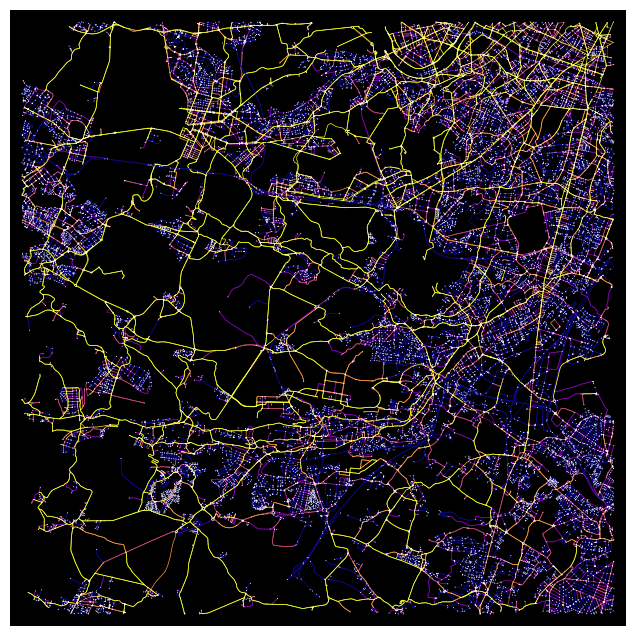

In [130]:
# get a color for each edge, by grade, then plot the network
ec = ox.plot.get_edge_colors_by_attr(G, "popularity", cmap="plasma", num_bins=5, equal_size=False)
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=0.5, node_size=0.5, bgcolor="k")

## Save

In [131]:
# ox.io.save_graphml(G, filepath='graph_with_popularity.graphml', gephi=False, encoding='utf-8')    # save graph as map.graphml for later if needed

ox.io.save_graphml(G, filepath='graph_with_popularity_South.graphml', gephi=False, encoding='utf-8')    # save graph as map.graphml for later if needed


import os
import datetime
import networkx as nx

# Function to generate a new filename with increment and timestamp
def generate_filename(base_name, extension):
    # Get current date and time
    now = datetime.datetime.now()
    timestamp = now.strftime('%Y%m%d_%H%M%S')

    # Initialize counter
    counter = 1
    while True:
        # Generate filename with counter and timestamp
        filename = f"{base_name}_{timestamp}_{counter}.{extension}"
        if not os.path.exists(filename):
            return filename
        counter += 1

# Function to convert attributes to supported types
def sanitize_attributes(G):
    for node, data in G.nodes(data=True):
        for key, value in data.items():
            if isinstance(value, (list, dict)):
                data[key] = str(value)
    
    for u, v, data in G.edges(data=True):
        for key, value in data.items():
            if isinstance(value, (list, dict)):
                data[key] = str(value)

# Example usage with your function
def save_graph_with_increment(G, base_name='graph_with_popularity', extension='graphml'):
    filepath = generate_filename(base_name, extension)
    sanitize_attributes(G)
    ox.io.save_graphml(G, filepath, gephi=False, encoding='utf-8')

# Save the graph with the new naming convention
save_graph_with_increment(G)


# NEW START Load existing graph

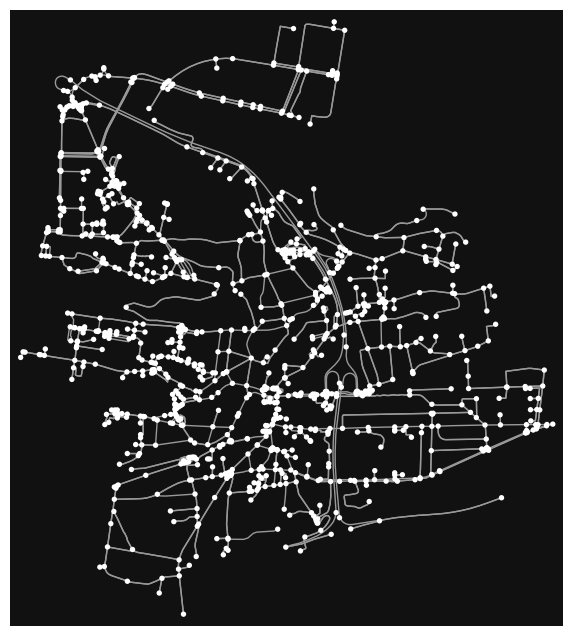

gps coord limits: [48.689952899999994 48.7181246] [2.1696922 2.2080455]
n: 1071
m: 2181
k_avg: 4.072829131652661
edge_length_total: 137377.145
edge_length_avg: 62.98814534617148
streets_per_node_avg: 2.9131652661064424
streets_per_node_counts: {0: 0, 1: 117, 2: 10, 3: 797, 4: 143, 5: 4}
streets_per_node_proportions: {0: 0.0, 1: 0.1092436974789916, 2: 0.009337068160597572, 3: 0.7441643323996265, 4: 0.13352007469654528, 5: 0.003734827264239029}
intersection_count: 954
street_length_total: 79317.987
street_segment_count: 1279
street_length_avg: 62.01562705238467
circuity_avg: 1.0561663776377652
self_loop_proportion: 0.0023455824863174357


In [2]:

# G = ox.io.load_graphml('graph_with_popularity_Orsay.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)

# G = ox.io.load_graphml('graph_with_all_attributes_Orsay.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)



# G = ox.io.load_graphml('graph_with_popularity.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)

# G = ox.io.load_graphml('graph_with_all_attributes.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)


# G = ox.io.load_graphml('graph_with_all_attributes_filtered.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)

# G = ox.io.load_graphml('graph_South_with_all_attributes_filtered.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)

G = ox.io.load_graphml('graph_Orsay_with_all_attributes_filtered.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)

ox.plot_graph(G)

gdf_nodes, gdf_edges = ox.graph_to_gdfs(G, nodes=True, edges=True)                                                      # Go with GeoPandas GeoDataFrames
gps_x_min, gps_x_max = min(gdf_nodes['x'])+0.000001, max(gdf_nodes['x'])-0.000001
gps_y_min, gps_y_max = min(gdf_nodes['y'])+0.000001, max(gdf_nodes['y'])-0.000001
print(f'gps coord limits: [{gps_y_min} {gps_y_max}] [{gps_x_min} {gps_x_max}]')


stats = ox.stats.basic_stats(G)
for key, value in stats.items():
    print(f"{key}: {value}")

### Export the graph in output_graph.xy that can be read by the NWMOA* algorithm in C++

In [6]:
import math
import random

# Create a mapping from the original node IDs to sequential IDs
node_mapping = {old_id: new_id for new_id, old_id in enumerate(G.nodes())}

# Create a dictionary for quick node lookup by the new sequential id
node_dict = {node_mapping[node]: (data['x'], data['y'], int(data['elevation'])) for node, data in G.nodes(data=True)}

# Prepare the output in the required format
output_lines = []

output_lines.append(f"# warthog xy Energy graph \n")
output_lines.append(f"# this file is formatted as follows: [header data] [node data] [edge data] \n")
output_lines.append(f"# header format: nodes [number of nodes] edges [number of edges]  \n")
output_lines.append(f"# node data format: v [id] [x] [y] [elevation] \n")
output_lines.append(f"# edge data format: e [from_node_id] [to_node_id] [length] [1000 - height_gain] [popularity] [street_width] [100*random] \n")
output_lines.append(f"# \n")
output_lines.append(f"# 32bit integer values are used throughout. \n")
output_lines.append(f"# Identifiers are all zero indexed. \n")
output_lines.append(f"# \n")
output_lines.append(f"nodes {len(G.nodes)} edges {len(G.edges)} objectives {2} \n")

# Add nodes to the output
for node, (x, y, elevation) in node_dict.items():
    output_lines.append(f"v {node} {int(x*1e6)} {int(y*1e6)} {elevation} \n")

# Add edges to the output
for from_node, to_node, data in G.edges(data=True):
    length = math.ceil(float(data.get('length', 0)))
    height_gain = int(max(0, 10 * float(data.get('height_gain', 0))))
    popularity = math.ceil(float(data.get('popularity', 0)))
    street_width = math.ceil(10 * float(data.get('street_width', 0)))
    obj5 = int(100*random.random()) # random objctive 5

    # Use the mapped node IDs
    new_from_node = node_mapping[from_node]
    new_to_node = node_mapping[to_node]
    # output_lines.append(f"e {new_from_node} {new_to_node} {length} {1000-height_gain} {popularity} {street_width} {obj5} \n")
    output_lines.append(f"e {new_from_node} {new_to_node} {length} {height_gain} \n")

  

# Save the output to a new file
output_file_path = 'graph_Paris_south_2_objectives.xy'
with open(output_file_path, 'w') as file:
    file.writelines(output_lines)

print(f"Graph saved to {output_file_path}")


Graph saved to graph_Paris_south_2_objectives.xy


0.5859777448800455


## remove not allowed path and keep only the path (for road bike) for bike one from popularity

In [134]:
allowed_highway_types = [
    "motorway",
    "trunk",
    "primary",
    "secondary",
    "tertiary",
    "unclassified",
    "residential",
    "living_street",
    "service",
    "cycleway",
    "busway",
    "road",
    "unknown",
    "bus_guideway",
    "motorway_link",
    "trunk_link",
    "primary_link",
    "secondary_link",
    "tertiary_link"
]


min_popularity = 1

# Filter the graph by allowed highway types
G_filtered_highway = filter_by_highway_types(G, allowed_highway_types)


# Filter the graph by minimum popularity
G_filtered_popularity = filter_by_popularity(G_filtered_highway, min_popularity)

# Remove isolated nodes
G.remove_nodes_from(list(nx.isolates(G_filtered_popularity)))

# Extract the largest weakly connected component
if not nx.is_weakly_connected(G):
    largest_wcc_nodes = max(nx.weakly_connected_components(G), key=len)
    G = G.subgraph(largest_wcc_nodes).copy()

ox.io.save_graphml(G, filepath='graph_South_with_all_attributes_filtered.graphml', gephi=False, encoding='utf-8')    # save graph as map.graphml for later if needed

# ox.plot_graph(G_filtered_highway)
# ox.plot_graph(G_filtered_popularity)
# ox.plot_graph(G)


## Shows the graph in Open street map with color coded 
### Can be skiped to go after


In [3]:
edges_gdf = ox.graph_to_gdfs(G, nodes=False, edges=True)

# Ensure the 'grade' and 'popularity' columns are present
if 'grade' not in edges_gdf.columns or 'popularity' not in edges_gdf.columns:
    raise ValueError("The graph edges do not contain 'grade' or 'popularity' attributes.")


# Convert 'grade' and 'popularity' columns to numeric, forcing errors to NaN
edges_gdf['grade'] = pd.to_numeric(edges_gdf['grade'], errors='coerce')
edges_gdf['popularity'] = pd.to_numeric(edges_gdf['popularity'], errors='coerce')

# Drop rows where 'grade' or 'popularity' could not be converted to numeric values
edges_gdf = edges_gdf.dropna(subset=['grade', 'popularity'])


# Filter edges 
# filtered_edges_gdf = edges_gdf[(edges_gdf['grade'] >= 0) & (edges_gdf['grade'] <= 0.2) & edges_gdf['popularity'] > 100]
filtered_edges_gdf = edges_gdf[(edges_gdf['grade'] >= 0) & (edges_gdf['grade'] <= 0.2)]


# Use the explore method to visualize the graph
# Color by 'grade' and add tooltips for 'grade' and 'popularity'
map = filtered_edges_gdf.explore(
    column='grade',               # Column to visualize
    cmap='inferno',               # Colormap for 'grade' 
    legend=True,                  # Show legend
    tooltip=['grade', 'popularity'], # Columns to show in the tooltip
    popup=True,                   # Show popups
    style_kwds=dict(weight=2),    # Line weight
    marker_kwds=dict(radius=6)    # Marker radius
)

''' 
viridis: Purple to yellow (sequential)
plasma: Dark blue to bright yellow (sequential)
magma: Dark purple to orange (sequential)
inferno: Dark purple to bright yellow (sequential)
cividis: Blue to yellow (sequential, color vision deficiency friendly)
'''

# Display the map
map

ImportError: The 'folium', 'matplotlib' and 'mapclassify' packages are required for 'explore()'. You can install them using 'conda install -c conda-forge folium matplotlib mapclassify' or 'pip install folium matplotlib mapclassify'.

### Plot edge based on a given criteria such as popularity, travel_time, speed_kph, grade_abs, grade, length, maxspeed

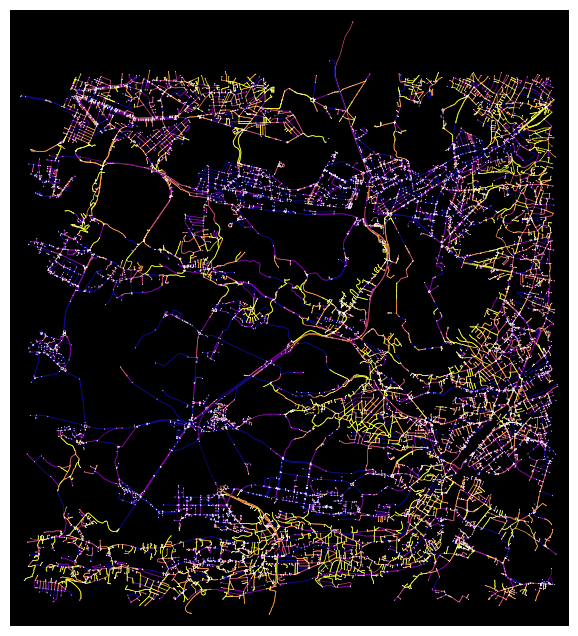

In [33]:
# get a color for each edge, by grade, then plot the network
ec = ox.plot.get_edge_colors_by_attr(G, "grade_abs", cmap="plasma", num_bins=5, equal_size=True)
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=0.5, node_size=0.5, bgcolor="k")

In [ ]:
ox.plot.plot_figure_ground(G, color='w')

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np

# Load your graph (example with a predefined graph)
# G = ox.graph_from_place("Piedmont, California, USA", network_type="drive")

# Parameters
color_attr = "grade_abs"
color_cmap = "plasma"
color_num_bins = 5
color_equal_size = True

opacity_attr = "popularity"
opacity_min = 0.3
opacity_max = 1.0

figsize = (100, 100)
bgcolor = "k"
node_color = "r"
node_size = 0
show = True
save = True
filepath = "graph_plot.png"
dpi = 300
bbox = None

# Define street widths based on highway types
street_widths = {
    "motorway": 4,
    "trunk": 3,
    "primary": 2.5,
    "secondary": 2,
    "tertiary": 1.5,
    "residential": 1,
    "service": 0.5,
    'unclassified': 0.5
}

def get_street_width(d, default_width=1):
    highway = d.get('highway')
    if isinstance(highway, list):  # In case 'highway' is a list, take the first element
        highway = highway[0]
    return street_widths.get(highway, default_width)

def get_numeric_attribute_values(G, attribute):
    values = []
    for u, v, k, d in G.edges(keys=True, data=True):
        try:
            value = float(d[attribute])
        except (ValueError, TypeError):
            value = np.nan
        values.append(value)
    return values

# Get edge colors based on color attribute
edge_colors = ox.plot.get_edge_colors_by_attr(G, color_attr, cmap=color_cmap, num_bins=color_num_bins, equal_size=color_equal_size)

# Get edge linewidths based on street types (highway attribute)
linewidths = [get_street_width(d) for u, v, k, d in G.edges(keys=True, data=True)]

# Add street_width values to each edge in the graph
for _, _, _, data in G.edges(keys=True, data=True):
    data["street_width"] = get_street_width(data)

# Get edge opacities based on opacity attribute
opacities = []
attr_values = get_numeric_attribute_values(G, opacity_attr)
attr_min = np.nanmin(attr_values)
attr_max = np.nanmax(attr_values)
for value in attr_values:
    if np.isnan(value):
        opacities.append(opacity_min)
    else:
        normalized_value = (value - attr_min) / (attr_max - attr_min)
        opacities.append(opacity_min + normalized_value * (opacity_max - opacity_min))


# Plot the graph
fig, ax = ox.plot_graph(
    G,
    figsize=figsize,
    bgcolor=bgcolor,
    node_color=node_color,
    node_size=node_size,
    node_alpha=None,
    node_edgecolor="none",
    node_zorder=1,
    edge_color=edge_colors,
    edge_linewidth=linewidths,
    edge_alpha=opacities,
    show=False,
    close=False,
    save=False,
    filepath=None,
    dpi=dpi,
    bbox=bbox
)

# Add colorbar if color_attr is used
sm = plt.cm.ScalarMappable(cmap=color_cmap, norm=plt.Normalize(
    vmin=np.nanmin([d[color_attr] for u, v, k, d in G.edges(keys=True, data=True) if color_attr in d and d[color_attr] is not None]), 
    vmax=np.nanmax([d[color_attr] for u, v, k, d in G.edges(keys=True, data=True) if color_attr in d and d[color_attr] is not None])))
sm._A = []  # For the scalar mappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(color_attr)

# Save and/or show the plot
if save and filepath:
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight')

if show:
    plt.show()

plt.close(fig)


# Calculate shortest paths, considering grade impedance

May be consider or test OSMnx + igraph for faster performance

### Choose origin to optimize

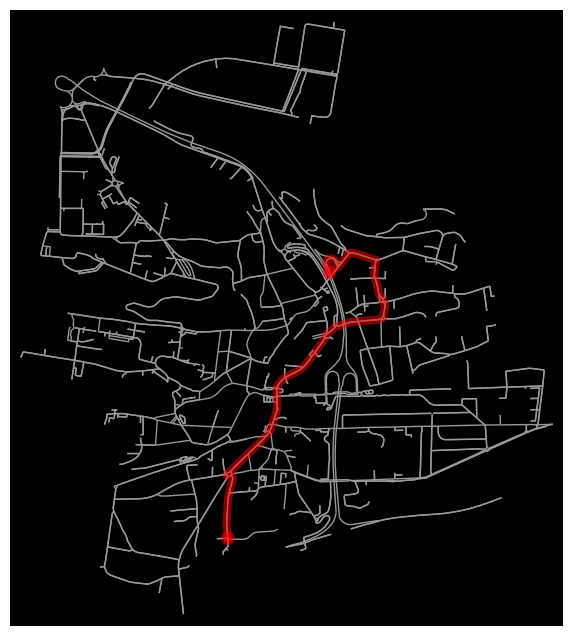

2375.956

In [4]:
# select an origin and destination node (here the first and last) 
origin = list(G.nodes)[0]
destination = list(G.nodes)[-1]


# origin_y, origin_x = (48.766561, 2.230352) # Bievres
# destination_y, destination_x =(48.817901, 2.256812) # Issy


# origin_y, origin_x = (48.73, 2.26) # Massy
# destination_y, destination_x = (48.74, 2.30) # Antony


# origin_y, origin_x = (48.821268, 2.334300) # Bd Jourdan Paris
# destination_y, destination_x = (48.707113, 2.173965) # Aimé Cotton

# origin_y, origin_x = (48.707680229382355, 2.2400589417726926) # Palaiseau
# destination_y, destination_x = (48.706562842057394, 2.0744209900739583) # St Remy

# origin = ox.nearest_nodes(G, origin_x, origin_y)
# destination = ox.nearest_nodes(G, destination_x, destination_y)

# Find the shortest path
route = nx.shortest_path(G, origin, destination, weight='length')

# Plot the graph
fig, ax = ox.plot_graph_route(G, route, route_linewidth=6, node_size=0, bgcolor='k')

plt.show()

calculate_total_attributes(G,route)


In [7]:
print(origin)
print(node_mapping[origin])

print(destination)
print(node_mapping[destination])

print(route)

7891467998
14066
7728123860
13953
[7891467998, 253869365, 253360141, 10155613696, 253360140, 218318735, 218318729, 218318889, 10693664609, 218318694, 218318684, 218318761, 218318248, 218318388, 1720377931, 1640804725, 208653783, 208653833, 150743380, 1275549067, 1275548849, 1275549210, 1275548997, 150743512, 1275549075, 150743470, 1275549331, 526296951, 526296933, 526296906, 526297014, 150744843, 6058271687, 150744969, 604013966, 141944621, 1275549282, 150743213, 604013652, 1416447397, 8567996948, 5303333105, 5237123227, 10997301273, 141943306, 10316844580, 141943545, 1562295406, 10316832145, 8569797843, 2623778926, 10025651502, 2623778940, 150745113, 604034837, 141941894, 141942132, 141942271, 141942283, 141942242, 814100261, 814100952, 814100821, 814100626, 814100366, 814100080, 814100105, 1476546373, 257800681, 150744603, 150744521, 1476546396, 2655851923, 150744542, 11803432599, 150744561, 4294778337, 6429000793, 982581711, 7817826311, 5179952996, 150744579, 7046363065, 7046363074,

## PLot path calculated by the optimized C++ code that use the mapin in id_names

Path with original IDs: [7891467998, 253869365, 253360141, 10155613696, 253360140, 218318735, 218318729, 218318889, 10693664609, 218318694, 218318684, 218318761, 218318248, 218318388, 1720377931, 1640804725, 208653783, 208653833, 150743380, 1275549067, 1275548849, 1275549210, 1275548997, 150743512, 1275549075, 150743470, 1275549331, 526296951, 526296933, 526296906, 526297014, 150744843, 6058271687, 150744969, 604013966, 141944621, 1275549282, 150743213, 604013652, 1416447397, 8567996948, 5303333105, 5237123227, 10997301273, 141943306, 10316844580, 141943545, 1562295406, 10316832145, 8569797843, 2623778926, 10025651502, 2623778940, 150745113, 604034837, 141941894, 141942132, 141942271, 141942283, 141942242, 814100261, 814100952, 814100821, 814100626, 814100366, 814100080, 814100105, 1476546373, 257800681, 150744603, 150744521, 1476546396, 2655851923, 150744542, 11803432599, 150744561, 4294778337, 6429000793, 982581711, 7817826311, 5179952996, 150744579, 7046363065, 7046363074, 704636307

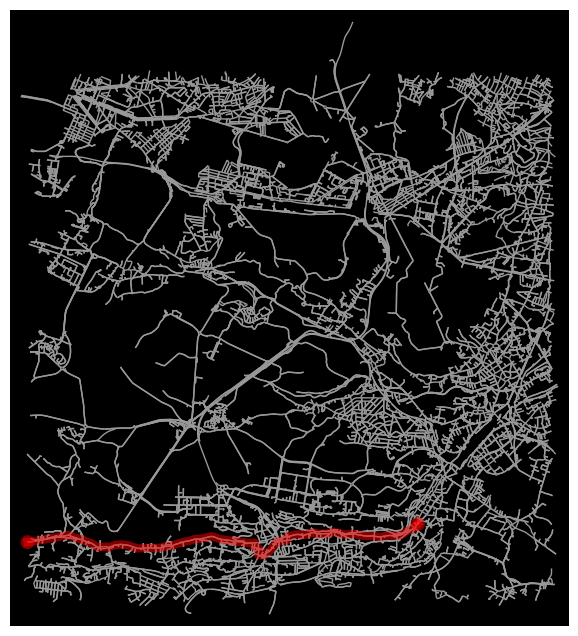

In [14]:
# Assuming node_mapping is already created and contains the mapping from old_id to new_id

# Reverse the mapping: from new_id to old_id
reversed_node_mapping = {new_id: old_id for old_id, new_id in node_mapping.items()}

# Example path with new IDs

new_id_path = [14066,3157,3057,15474,3056,2361,2360,2363,15640,2359,2358,2362,2328,2339,7518,7315,2111,2114,837,6217,6200,6224,6211,839,6219,838,6234,4971,4970,4969,4972,860,12414,862,5193,759,6228,830,5192,6692,14415,11714,11677,15831,748,15571,752,7115,15569,14416,9558,15361,9559,867,5204,725,726,729,730,728,5667,5681,5678,5674,5670,5658,5660,6832,3216,851,845,6833,9661,846,16469,847,11090,12985,5823,14023,11634,848,13524,13528,13529,13526,6598,13214,5161,13070,13212,3385,13209,2271,15282,12983,5172,15284,5169,9874,7141,3382,3380,3378,11082,3379,5165,5162,9775,6596,6597,4575,4576,3387,13909,4831,13908,2272,7143,7144,2731,7083,6551,6550,7087,10552,7086,10550,15560,6876,6875,7124,15559,5718,5009,16282,13954,5605,13366,5006,7085,13953]
new_id_path = [14066,3157,3057,15474,3056,2361,2360,2363,15640,2359,2358,2362,2328,4967,4968,9988,3692,3693,6202,5248,5249,4962,6052,4560,4961,6056,6047,861,6790,4805,4807,4808,7,2532,2518,2529,7091,2530,3689,10911,6425,9909,9927,15625,9926,15859,9925,11424,15856,10977,14852,15295,13889,11427,10065,10828,13989,13990,13993,13988,13986,6847,6841,4948,6843,6972,3948,6846,3949,6844,4570,4569,10543,15341,15340,15296,6840,7086,10550,15560,6876,6875,7124,15559,5718,5009,16282,13954,5605,13366,5006,7085,13953]

# and for normal hehgt

new_id_path = [14066,3157,3057,15474,3056,2361,3067,15653,12290,7229,7230,16248,12957,12954,15644,2357,9364,10297,7227,2331,14442,14440,10255,4931,2330,2335,2334,2333,2342,2332,7543,2186,2185,10240,8679,2184,2183,831,6221,4554,2187,3495,2189,766,6227,763,764,758,759,6228,830,5192,6692,14415,11714,11677,15831,748,15571,752,7115,15569,14416,9558,15361,9559,867,5204,725,732,3233,6707,724,723,5641,6704,7604,722,736,15574,14046,737,12242,7595,3229,7598,7594,7596,7599,3228,3227,11603,3226,11459,11599,11604,11605,11005,12398,11006,3224,7600,11376,12043,7593,10464,12041,11373,5862,12047,5858,4960,3223,10530,10531,9951,2291,11460,2290,10554,14480,11093,7192,11092,11071,11072,10306,10359,2278,2288,13402,2289,2287,9831,2286,6614,13201,11088,13531,11673,13203,6619,9571,13196,11466,2742,6602,11468,6622,2744,12403,6830,16227,13222,4950,16228,4952,10629,14843,14838,14837,9774,6594,6596,6597,4575,4576,3387,13909,4831,13908,2272,7143,7144,2731,7083,7081,7084,14477,15560,6876,6875,7124,15559,5718,5009,16282,13954,5605,13366,5006,7085,13953]
new_id_path = [14066,3157,3057,15474,3056,2361,2360,2363,15640,2359,2358,2362,2328,2339,7518,7315,2111,2114,837,6217,6200,6224,6211,839,6219,838,6234,4971,4970,4969,4972,860,12414,862,5193,759,6228,830,5192,6692,14415,11714,11677,15831,748,15571,752,7115,15569,14416,9558,15361,9559,867,5204,725,726,729,730,728,5667,5681,5672,5681,5678,5674,5670,870,6831,5658,5660,6832,3216,851,845,6833,9661,846,16469,847,11090,12985,5823,14023,11634,848,13524,13528,13529,13526,6598,13214,5161,13070,13212,3385,13209,2271,15282,12983,5172,15284,5169,9874,7141,3382,3380,3378,11082,3379,5165,5162,9775,6596,6597,4575,4576,3387,13909,4831,13908,2272,7143,7144,2731,7083,6551,6550,7087,10552,7086,10550,15560,6876,6875,15555,15554,15558,15559,5718,5009,16282,13954,5605,13366,5006,7085,13953]

new_id_path = [14066,3157,3057,15474,3056,2361,2360,2363,15640,2359,2358,2362,2328,2339,7518,7315,2111,2114,837,6217,6200,6224,6211,839,6219,838,6234,4971,4970,4969,4972,860,12414,862,5193,759,6228,830,5192,6692,14415,11714,11677,15831,748,15571,752,7115,15569,14416,9558,15361,9559,867,5204,725,726,729,730,728,5667,5681,5678,5674,5670,5658,5660,6832,3216,851,845,6833,9661,846,16469,847,11090,12985,5823,14023,11634,848,13524,13528,13529,13526,6598,13214,5161,13070,13212,3385,13209,2271,15282,12983,5172,15284,5169,9874,7141,3382,3380,3378,11082,3379,5165,5162,9775,6596,6597,4575,4576,3387,13909,4831,13908,2272,7143,7144,2731,7083,6551,6550,7087,10552,7086,10550,15560,6876,6875,7124,15559,5718,5009,16282,13954,5605,13366,5006,7085,13953]

# Convert the path to the old IDs
old_id_path = [reversed_node_mapping[new_id] for new_id in new_id_path]

print("Path with original IDs:", old_id_path)

# Plot the graph
fig, ax = ox.plot_graph_route(G, old_id_path, route_linewidth=6, node_size=0, bgcolor='k')

## Calculation of an impedance attribute (for single objective)

Moslty useful when the  objective function is additive (sum of the cost value per edge)

Among the possible choice of value combinaition are:

Linear combinaition with weight
Polynomial Combination
Exponential Combination
Logarithmic Combination
Rational Function Combination
Weighted Harmonic Mean
Generalized Mean (Power Mean)
Custom Functions

In [7]:
# Define weights for each criterion in a dictionary
weights = {
    # "length": 1.0,
    # grade_abs": 1.0,
    "popularity": 1,
    "street_width": 1,
    # "height_gain": 1.0,
    # Add more criteria here with their weights
}

# Normalize function
def normalize(value, min_value, max_value):
    return (value - min_value) / (max_value - min_value) if max_value != min_value else 0


# Define a general impedance function
def impedance(data, criteria, weights, mins, maxs):
    impedance_value = 0
    for criterion in criteria:
        value = float(data.get(criterion, 0))  # Convert to float
        normalized_value = normalize(value, mins[criterion], maxs[criterion])
        impedance_value += weights[criterion] * normalized_value
    return impedance_value

# Calculate min and max values for normalization
criteria = list(weights.keys())
mins = {criterion: min(float(d[criterion]) for _, _, _, d in G.edges(keys=True, data=True) if criterion in d) for criterion in criteria}
maxs = {criterion: max(float(d[criterion]) for _, _, _, d in G.edges(keys=True, data=True) if criterion in d) for criterion in criteria}

# Add impedance values to each edge in the graph
# for _, _, _, data in G.edges(keys=True, data=True):
#     data["impedance"] = impedance(data, criteria, weights, mins, maxs)


# Add hoc impedance
for _, _, _, data in G.edges(keys=True, data=True):
    d_plus = float(data["height_gain"])
    if d_plus > 0:
        # data["impedance"] = 1/(20 + d_plus)
        # data["impedance"] = 1/(float(data["length"]) * d_plus * (float(data['popularity'])+2) )
        # data["impedance"] = -  d_plus /(float(data["length"]))
        # data["impedance"] = 1/(data["length"] * d_plus )
        # data["impedance"] = data["length"] - 3*d_plus 
        # data["impedance"] = data["length"] - d_plus 
        # data["impedance"] = data["length"]/(float(data["popularity"])+2)
        # data["impedance"] = float(data["street_width"])*data["length"]/(float(data["popularity"])+2)
        data["impedance"] = float(data["street_width"])*data["length"]/(float(data["popularity"])+100)
    else:
        data["impedance"] = 1

       

Execution time: 0.4255681037902832 seconds
Length: 13347.111 m
Length: 145.07799999999995 m


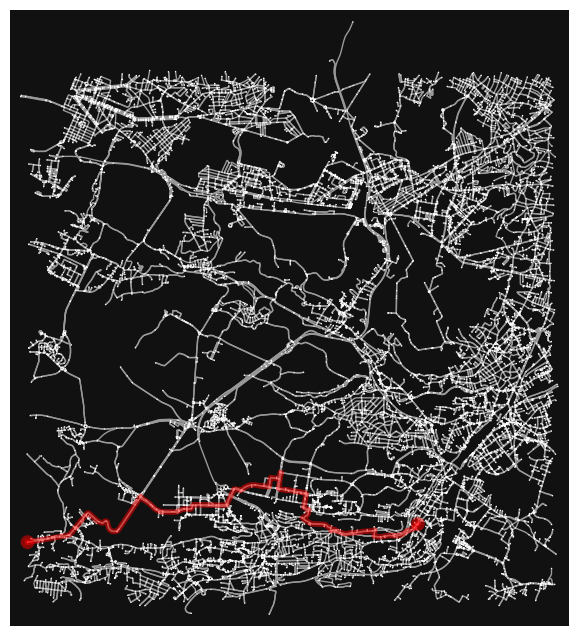

In [8]:
# how many CPUs do you have
nb_cpus = mp.cpu_count()

# Start the timer
start_time = time.time()



# Example: Find the shortest path based on impedance
# origin = ox.nearest_nodes(G, X=origin_x, Y=origin_y)
# destination = ox.nearest_nodes(G, X=destination_x, Y=destination_y)

# 0.1 s 
# shortest_path = nx.shortest_path(G, origin, destination, weight='impedance')
shortest_path = nx.bellman_ford_path(G, origin, destination, weight='impedance')

# 0.62 s for cpus=1
# shortest_path = ox.distance.shortest_path(G, origin, destination, weight='impedance', cpus=1)

# 0.48 s for cpus= nb_cpus
# shortest_path = ox.distance.shortest_path(G, origin, destination, weight='impedance', cpus=nb_cpus)

''' may be use and tst using several chips etc.. 

ox.shortest_path(G, origin, destination, weight="impedance")
'''



# End the timer
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time
print(f"Execution time: {elapsed_time} seconds")

print(f"Length: {calculate_total_attributes(G, shortest_path, 'length')} m")
print(f"Length: {calculate_total_attributes(G, shortest_path, 'height_gain', True)} m")



fig, ax = ox.plot_graph_route(G, shortest_path, route_color='r', route_linewidth=4, node_size=1)

## Constrained Shortest Path (CSP)


For instance:
    minimize distance while satisfying a minimum elevation gain
    or
    maximun  elevation gain while satisfying a maximum distance


## pymoo: Multi-objective Optimization in Python

In [43]:
pip install -U pymoo

Note: you may need to restart the kernel to use updated packages.


In [44]:
import importlib
import graph_utils  # Import your module

# Reload the Strava_utils module to ensure it's the most up-to-date version
importlib.reload(graph_utils)
from graph_utils import *

### Create the problem

an optimization problem be defined by:

        min    f_m(x)          m = 1, ..., M
        s.t.   g_j(x) ≤ 0      j = 1, ..., J
               h_k(x) = 0      k = 1, ..., K
               x_i^L ≤ x_i ≤ x_i^U  i = 1, ..., N
               x ∈ Ω


## Group nodes (no used now)

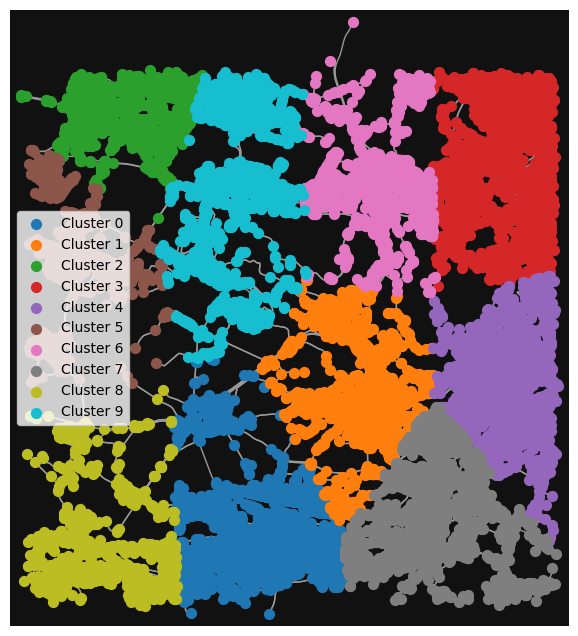

In [150]:
from sklearn.cluster import KMeans

# Extract nodes and their coordinates
nodes = list(G.nodes)
coords = np.array([(G.nodes[node]['x'], G.nodes[node]['y']) for node in nodes])

# Number of clusters
num_clusters = 10

# Initialize and fit K-Means
kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(coords)

# Get the cluster labels for each node
labels = kmeans.labels_

# Plot all nodes
fig, ax = ox.plot_graph(G, show=False, close=False)

# Plot nodes with different colors for different clusters
colors = plt.cm.get_cmap('tab10', num_clusters)
for cluster_num in range(num_clusters):
    cluster_nodes = [coords[i] for i in range(len(nodes)) if labels[i] == cluster_num]
    cluster_x, cluster_y = zip(*cluster_nodes)
    ax.scatter(cluster_x, cluster_y, c=[colors(cluster_num)], label=f'Cluster {cluster_num}', s=50)

plt.legend()
plt.show()

## Creation of parameters of the problem:
x= waypoints (in fact latitude, longitude)

In [57]:
import importlib
import graph_utils  # Import your module
importlib.reload(graph_utils)
from graph_utils import *

import numpy as np
from pymoo.core.problem import ElementwiseProblem

# Define the lower and upper bounds for the waypoints
n_waypoints = 10
xl = np.array([[gps_y_min, gps_x_min]] * n_waypoints)  # Lower bounds for latitude and longitude
xu = np.array([[gps_y_max, gps_x_max]] * n_waypoints)  # Upper bounds for latitude and longitude

start = origin
end = destination

# Define the lower and upper bounds for the total route length
km_min = 50
km_max = 60
duplicate_distance_max_km = 2

class RouteOptimizationProblem(ElementwiseProblem):
    
    def __init__(self, n_waypoints, xl, xu, G):
        super().__init__(n_var=n_waypoints * 2,
                         n_obj=1,
                         n_ieq_constr=3,
                         xl=xl.flatten(),
                         xu=xu.flatten())
        self.G = G

    def _evaluate(self, x, out, *args, **kwargs):
        waypoints = x.reshape((-1, 2))

        point_y = waypoints[:, 0]
        point_x = waypoints[:, 1]
        # Find the nearest nodes for each waypoint
        nodes = list(ox.nearest_nodes(self.G, point_x, point_y))  # Convert to list
        # Insert 'start' at the beginning and 'end' at the end
        nodes.insert(0, start)
        nodes.append(end)

        # Debug print statements
        # print("Waypoints:", waypoints)
        # print("Nearest nodes:", nodes)

        route = calculate_route(self.G, nodes, weight='length')

        # Debug print statement
        # print("Route:", route)

        if not route:
            f1 = float('inf')  # or a large number indicating an invalid route
            f2 = float('inf')  # or a large number indicating an invalid route
            f3 = 0
            g1 = f1 - 1000 * km_max 
            g2 = 1000 * km_min - f1
            g3 = f3 - 1000 * duplicate_distance_max_km
        else:
            f1 = calculate_total_attributes(self.G, route, 'height_gain', positive_only=True)
            f2, f3 = calculate_total_attributes_multiplekm(self.G, route, 'length') # total_lenght, duplicate_distance
            # f2 = calculate_total_attributes(self.G, route, 'length') # total_lenght, duplicate_distance
            f3 = 0

            # Constraints on route length (min < f1 < max) and on duplicate_distance
            g1 = f1 - 1000 * km_max 
            g2 = 1000 * km_min - f1
            g3 = f3 - 1000 * duplicate_distance_max_km
        
        out["F"] = [f2/f1] # optimized length/height
        out["G"] = [g1, g2,g3]

# Initialize the optimization problem
problem = RouteOptimizationProblem(n_waypoints, xl, xu, G)

### Possible Algorithms 

In [46]:
import numpy as np

from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.algorithms.moo.unsga3 import UNSGA3
from pymoo.problems import get_problem
from pymoo.optimize import minimize


# create the reference directions to be used for the optimization - just a single one here
ref_dirs = np.array([[1.0]])

# create the algorithm object
algorithm = UNSGA3(ref_dirs, pop_size=50)


In [50]:

# MOEAD


from pymoo.algorithms.moo.moead import MOEAD
from pymoo.optimize import minimize
from pymoo.problems import get_problem
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.visualization.scatter import Scatter


algorithm = MOEAD(
    ref_dirs,
    n_neighbors=15,
    prob_neighbor_mating=0.7,
)




In [58]:
# C-TAEA
 
from pymoo.algorithms.moo.ctaea import CTAEA
from pymoo.problems import get_problem
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

ref_dirs = np.array([[1.0]])

# create the algorithm object
algorithm = CTAEA(ref_dirs=ref_dirs)

In [28]:
# NSGA-II

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling

algorithm = NSGA2(
    pop_size=40,
    n_offsprings=10,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

In [59]:
# If needed, clear variables
del X
del F 
del res

NameError: name 'X' is not defined

In [60]:
from pymoo.termination import get_termination

# termination = get_termination("n_gen", 10)

termination = get_termination("time", "00:5:00")

from pymoo.optimize import minimize

res = minimize(problem,
               algorithm,
               termination,
               seed=1,
               save_history=True,
               verbose=True)

X = res.X
F = res.F


c:\Users\Daniel\anaconda3\Lib\site-packages\numpy\core\numeric.py:330: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |        1 |      1 |           INF |           INF |             - |             -


c:\Users\Daniel\anaconda3\Lib\site-packages\numpy\core\numeric.py:330: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


     2 |        2 |      1 |           INF |           INF |             - |             -


c:\Users\Daniel\anaconda3\Lib\site-packages\numpy\core\numeric.py:330: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


...

   163 |      163 |      1 |  4.861119E+04 |  4.861119E+04 |             - |             -


c:\Users\Daniel\anaconda3\Lib\site-packages\numpy\core\numeric.py:330: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


   164 |      164 |      1 |  4.861119E+04 |  4.861119E+04 |             - |             -


c:\Users\Daniel\anaconda3\Lib\site-packages\numpy\core\numeric.py:330: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


   165 |      165 |      1 |  4.861119E+04 |  4.861119E+04 |             - |             -


Route : Length = [82225.443] meters, Height Gain = [1388.8090000000002] meters
    
Route : Length = [82225.443, 82225.443] meters, Height Gain = [1388.8090000000002, 1388.8090000000002] meters
    
Route : Length = [82225.443, 82225.443, 82225.443] meters, Height Gain = [1388.8090000000002, 1388.8090000000002, 1388.8090000000002] meters
    
Route 1: Length = 82225.443 meters, Height Gain = 1388.8090000000002 meters
Route 2: Length = 82225.443 meters, Height Gain = 1388.8090000000002 meters
Route 3: Length = 82225.443 meters, Height Gain = 1388.8090000000002 meters


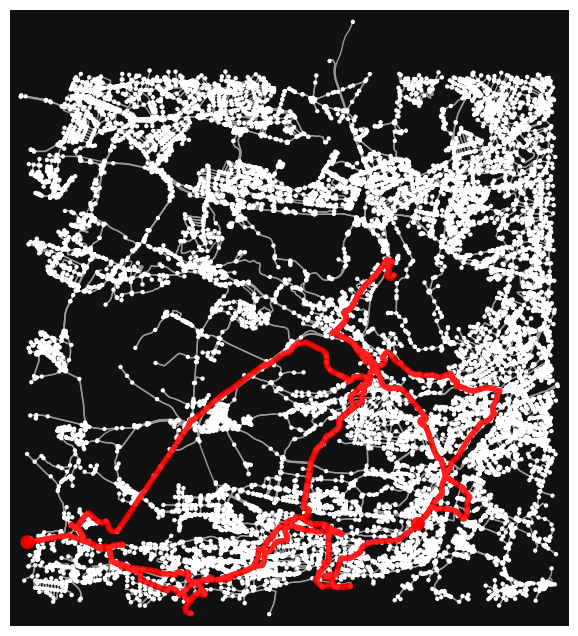

In [61]:
import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np  


# Extract solutions and objectives from the history
all_solutions = []
all_objectives = []

for entry in res.history:
    pop = entry.pop
    all_solutions.extend(pop.get("X"))
    all_objectives.extend(pop.get("F"))

all_solutions = np.array(all_solutions)
all_objectives = np.array(all_objectives)

# Sort and select the top num_routes based on the first objective
num_routes = 3
combined = np.hstack((all_solutions, all_objectives))
sorted_combined = combined[np.argsort(combined[:, -1])]
top_combined = sorted_combined[:num_routes]

# Separate solutions (X) and objectives (F) for the top routes
top_X = top_combined[:, :all_solutions.shape[1]]
top_F = top_combined[:, all_solutions.shape[1]:]





# Initialize lists for routes, lengths, and height gains
routes = []
route_lengths = []
route_height_gains = []

# Process each element in X
for x in top_X:
    if x.size % 2 != 0:
        x = top_X
    waypoints = x.reshape((-1, 2))
    point_y = waypoints[:, 0]
    point_x = waypoints[:, 1]
    nodes = list(ox.nearest_nodes(G, point_x, point_y))
    nodes.insert(0, start)
    nodes.append(end)
    route = calculate_route(G, nodes, weight='length')

    if route:
        routes.append(route)
        f1 = calculate_total_attributes(G, route, 'length')
        f2 = calculate_total_attributes(G, route, 'height_gain', positive_only=True)
        route_lengths.append(f1)
        route_height_gains.append(f2)
        print(f"Route : Length = {route_lengths} meters, Height Gain = {route_height_gains} meters")
        print('    ')
    else:
        print("No valid route found for:", x)

# Print the length and height gain of each route
for i, (length, height_gain) in enumerate(zip(route_lengths, route_height_gains)):
    print(f"Route {i+1}: Length = {length} meters, Height Gain = {height_gain} meters")

# Ensure there is at least one route to plot
if routes:
    if len(routes) == 1:
        # Plot a single route if only one is found
        fig, ax = ox.plot_graph_route(G, routes[0], route_color='r', route_linewidth=4, node_size=10)
    else:
        # Plot multiple routes if more than one is found
        fig, ax = ox.plot_graph_routes(G, routes, route_colors='r', route_linewidths=4, node_size=10)

    plt.show()
else:
    print("No valid routes to plot.")


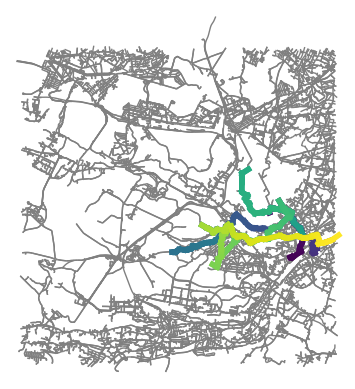

In [171]:

# Function to plot the route with a gradient
def plot_route_with_gradient(G, route):
    # Get the position of nodes for plotting
    node_positions = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

    # Generate a colormap
    cmap = plt.get_cmap('viridis')
    colors = [cmap(i / len(route)) for i in range(len(route))]

    # Plot the graph
    fig, ax = plt.subplots()
    ox.plot_graph(G, ax=ax, node_size=0, edge_color='gray', show=False, close=False)

    # Plot the route with gradient colors
    for i in range(len(route) - 1):
        node1 = route[i]
        node2 = route[i + 1]
        x = [node_positions[node1][0], node_positions[node2][0]]
        y = [node_positions[node1][1], node_positions[node2][1]]
        ax.plot(x, y, color=colors[i], linewidth=4)

    plt.show()

# Plot the route with gradient
plot_route_with_gradient(G, route)

In [170]:

# explore a route interactively
route_edges = ox.routing.route_to_gdf(G, route, weight="length")
route_edges.explore(tiles="OpenStreetMap", style_kwds={"weight": 5})

### Analyse convergence

In [20]:
[48.7060489 ,  2.18082011, 48.70938881,  2.19159161].reshape((-1, 2))

AttributeError: 'list' object has no attribute 'reshape'

100
At least one feasible solution in Generation 0 after 300 evaluations.
Whole population feasible in Generation 7 after 650 evaluations.


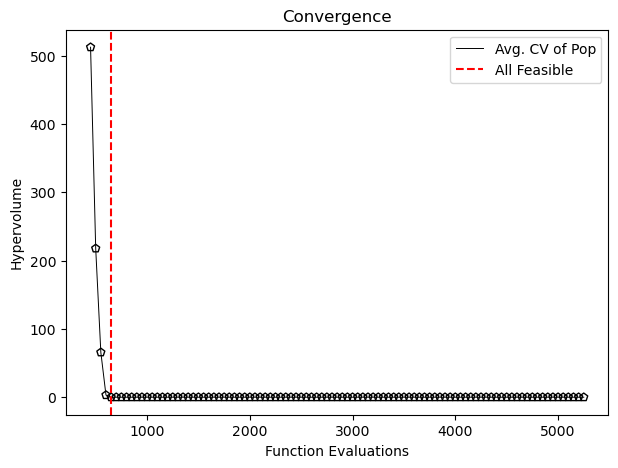

IndexError: index 1 is out of bounds for axis 0 with size 1

In [18]:
hist = res.history
print(len(hist))

n_evals = []             # corresponding number of function evaluations\
hist_F = []              # the objective space values in each generation
hist_cv = []             # constraint violation in each generation
hist_cv_avg = []         # average constraint violation in the whole population

for algo in hist:

    # store the number of function evaluations
    n_evals.append(algo.evaluator.n_eval)

    # retrieve the optimum from the algorithm
    opt = algo.opt

    # store the least contraint violation and the average in each population
    hist_cv.append(opt.get("CV").min())
    hist_cv_avg.append(algo.pop.get("CV").mean())

    # filter out only the feasible and append and objective space values
    feas = np.where(opt.get("feasible"))[0]
    hist_F.append(opt.get("F")[feas])

k = np.where(np.array(hist_cv) <= 0.0)[0].min()
print(f"At least one feasible solution in Generation {k} after {n_evals[k]} evaluations.")    


# replace this line by `hist_cv` if you like to analyze the least feasible optimal solution and not the population
vals = hist_cv_avg

k = np.where(np.array(vals) <= 0.0)[0].min()
print(f"Whole population feasible in Generation {k} after {n_evals[k]} evaluations.")

plt.figure(figsize=(7, 5))
plt.plot(n_evals, vals,  color='black', lw=0.7, label="Avg. CV of Pop")
plt.scatter(n_evals, vals,  facecolor="none", edgecolor='black', marker="p")
plt.axvline(n_evals[k], color="red", label="All Feasible", linestyle="--")
plt.title("Convergence")
plt.xlabel("Function Evaluations")
plt.ylabel("Hypervolume")
plt.legend()
plt.show()


approx_ideal = F.min(axis=0)
approx_nadir = F.max(axis=0)

from pymoo.indicators.hv import Hypervolume

metric = Hypervolume(ref_point= np.array([1.1, 1.1]),
                     norm_ref_point=False,
                     zero_to_one=True,
                     ideal=approx_ideal,
                     nadir=approx_nadir)

hv = [metric.do(_F) for _F in hist_F]

plt.figure(figsize=(7, 5))
plt.plot(n_evals, hv,  color='black', lw=0.7, label="Avg. CV of Pop")
plt.scatter(n_evals, hv,  facecolor="none", edgecolor='black', marker="p")
plt.title("Convergence")
plt.xlabel("Function Evaluations")
plt.ylabel("Hypervolume")
plt.show()

### Brute force algorithm: try all shortest path

In [91]:
import importlib
import Algorithms

# Reload the module to ensure the latest version is used
importlib.reload(Algorithms)

from Algorithms import *  # our function

start = origin
goal = destination
max_distance = 8000
min_elevation_gain = 300

path, elevation_gain = shortest_path_with_min_elevation_brute_force(G, start, goal, min_elevation_gain)
print(f"Path: {path}, Elevation Gain: {elevation_gain}")



'''

path, distance, elevation_gain = dijkstra_with_elevation_constraint(G, start, goal, min_elevation_gain)
print(f"Path: {path}, Distance: {distance}, Elevation Gain: {elevation_gain}")

path, gain = a_star_max_elevation(G, origin, destination, max_distance, elevation='elevation')
print(f"Path: {path}, Elevation Gain: {gain}")


path, distance, elevation_gain = bfs_min_distance_with_min_elevation(G, origin, destination, min_elevation_gain)
print(f"Path: {path}, Distance: {distance}, Elevation Gain: {elevation_gain}")
'''

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\Daniel\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Daniel\AppData\Local\Temp\ipykernel_2740\3433054817.py", line 14, in <module>
    path, elevation_gain = shortest_path_with_min_elevation(G, start, goal, min_elevation_gain)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Daniel\ownCloud\Code\python\gitlab\optimized-road\Algorithms.py", line 138, in shortest_path_with_min_elevation
    for path in nx.shortest_simple_paths(G, source, target, weight=weight):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<class 'networkx.utils.decorators.argmap'> compilation 9", line 3, in argmap_shortest_simple_paths_6
    import gzip
         ^^^^^^^
  File "c:\Users\Daniel\anaconda3\Lib\site-packages\networkx\utils\decorators.py", line 86, 

In [123]:

def find_paths_with_min_elevation(G, start, goal, min_elevation_gain):
    global best_path  # Use the global keyword to modify the global variable
    path_generator = nx.shortest_simple_paths(G, start, goal)
    count = 0
    total_elevation = 0
    max_elevation = 0

    while count < 10000  or total_elevation < min_elevation_gain:
        try:
            path = next(path_generator)
        except StopIteration:
            break

        total_elevation = 0
        for i in range(len(path) - 1):
            edge_data = G.get_edge_data(path[i], path[i + 1])
            total_elevation += float(edge_data.get('height_gain', 0))
        if total_elevation > max_elevation:
                max_elevation = total_elevation
                best_path = path
                print(f"Count: {count}, Best Elevation : {max_elevation}, Elevation Gain: {total_elevation}, Path {best_path}")
        count += 1

def convert_multigraph_to_graph(G):
    """
    Convert a G networkx.MultiDiGraph into a networkx.Graph

    Parameters:
    G (networkx.Graph): 

    Returns:
    networkx.MultiDiGraph
    """
    simple_graph = nx.Graph()
    for u, v, data in G.edges(data=True):
        if simple_graph.has_edge(u, v):
            if data.get('height_gain', 0) > simple_graph[u][v].get('height_gain', 0):
                simple_graph[u][v].update(data)
        else:
            simple_graph.add_edge(u, v, **data)
    return simple_graph

best_path = []
min_elevation_gain = 500
G_simple = convert_multigraph_to_graph(G)
find_paths_with_min_elevation(G_simple, origin, destination, min_elevation_gain)



Count: 0, Best Elevation : 256.076, Elevation Gain: 256.076, Path [7891467998, 253869365, 253360141, 10155613696, 253360140, 218318735, 218318729, 218318889, 10693664609, 218318694, 218318684, 218318761, 218318248, 511980757, 511980759, 3032496678, 294277005, 294277007, 1275548863, 635847347, 635847429, 511980093, 1126351045, 439208717, 511980092, 1126351117, 1126350905, 150744896, 1445661966, 471157372, 471157752, 471158681, 28389915, 243898177, 243898141, 1114038632, 243898174, 294269348, 4081430304, 1341514103, 2960408806, 2974017581, 10672657105, 2974017579, 11023159709, 2974017578, 4826726304, 11022218584, 4156312696, 9285942763, 9962724977, 7565236356, 4826726315, 3137372906, 3973861167, 7774269709, 6745955642, 7773489280, 1476633011, 1476632910, 506724014, 1476632971, 1531462109, 314692143, 1476632997, 314692144, 1476632978, 440243889, 8365462084, 1476632916, 9998410648, 9963843924, 1476632877, 1546407099, 3744616682, 10310782630, 1503147795, 1503147791, 1567666366, 10310782623,

KeyboardInterrupt: 

AttributeError: 'NoneType' object has no attribute 'values'

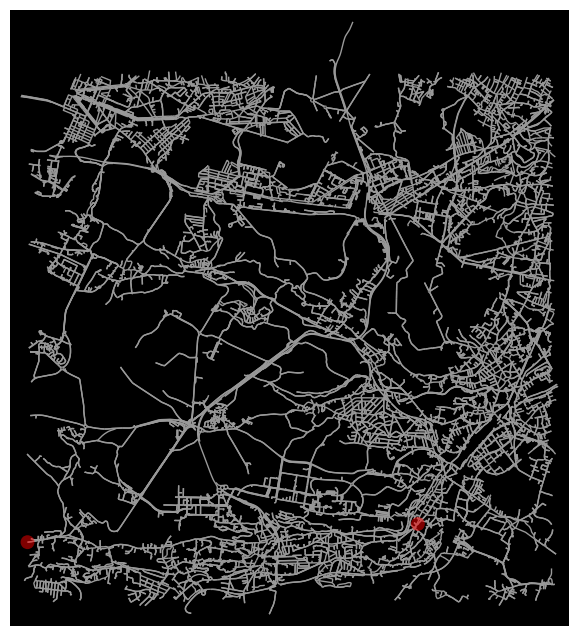

In [124]:

path = shortest_path

# Plot the shortest patt
fig, ax = ox.plot_graph_route(G, path, route_linewidth=6, node_size=0, bgcolor='k')

In [ ]:
ox.plot_graph(G, node_size=1, edge_color="#333333", bgcolor="k")

In [83]:

get_d_plus_total(G,shortest_path)

170.60500000000005

In [84]:
ox.distance.shortest_path(G, origin, destination, weight='length', cpus=1)

C:\Users\Daniel\AppData\Local\Temp\ipykernel_2740\690629460.py:1: FutureWarning: The `shortest_path` function has moved to the `routing` module. Calling it via the `distance` module will raise an error starting in the v2.0.0 release. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  ox.distance.shortest_path(G, origin, destination, weight='lenght', cpus=1)
c:\Users\Daniel\anaconda3\Lib\site-packages\osmnx\routing.py:74: UserWarning: The attribute 'lenght' is missing or null on some edges.
  _verify_edge_attribute(G, weight)


[7891467998,
 253869365,
 253360141,
 10155613696,
 253360140,
 218318735,
 218318729,
 218318889,
 10693664609,
 218318694,
 218318684,
 218318761,
 218318248,
 511980757,
 511980759,
 3032496678,
 294277005,
 294277007,
 1275548863,
 635847347,
 635847429,
 511980093,
 1126351045,
 439208717,
 511980092,
 1126351117,
 1126350905,
 150744896,
 1445661966,
 471157372,
 471157752,
 471158681,
 28389915,
 243898177,
 243898101,
 243898149,
 1554754885,
 243898170,
 294269348,
 4081430304,
 1341514103,
 2960408806,
 2974017581,
 10672657105,
 2974017579,
 11023159709,
 2974017578,
 4826726304,
 11022218584,
 4156312696,
 9285942763,
 9962724977,
 7565236356,
 4826726315,
 3137372906,
 3973861167,
 7774269709,
 7774269710,
 7774269716,
 7774269699,
 7773489280,
 1476633011,
 1476632910,
 506724014,
 1476632971,
 1531462109,
 314692143,
 1476632997,
 314692144,
 1476632978,
 440243889,
 440243860,
 3737690957,
 9998410655,
 9998410648,
 9963843924,
 1476632877,
 1546407099,
 3744616682,
 10

In [21]:
# Example usage
waypoints = [(48.78, 2.16), (48.78, 2.24), (48.73, 2.25), (48.70,2.26), (48.70, 2.19), (48.70, 2.11), (48.74, 2.14)]
n = 7
radius_meters = 4000  # 1000 meters

print(random_gps_waypoints_from_list(n, waypoints, radius_meters, gps_y_min, gps_y_max, gps_x_min, gps_x_max))


[(48.700256, 2.1183999), (48.7782326, 2.1867886), (48.7326822, 2.1457301), (48.7485693, 2.2243491), (48.7207282, 2.1765159), (48.7347325, 2.2519519), (48.699151, 2.2568393)]


# Bayesian optimization to find cycling routes that fit our needs

#### maximize d+ / 30 kms / do not go on the same route twice / (avoiding road with lot of vehicules)

In [13]:
!pip install scikit-optimize
from skopt import gp_minimize, gbrt_minimize, load
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args, cook_initial_point_generator
from skopt.callbacks import CheckpointSaver

In [14]:

# our_spot = (48.707680229382355,2.2400589417726926) # Palaiseau

our_spot = (48.805589, 2.259308) # Issy


starting_spot = our_spot      # (y, x)
# waypoints = random_gps_waypoints(3, gps_y_min, gps_y_max, gps_x_min, gps_x_max)           # run this if you want to get random waypoints

waypoints_center =  [(48.78, 2.16), (48.78, 2.24), (48.73, 2.25), (48.70,2.26), (48.70, 2.19), (48.70, 2.11), (48.74, 2.14)]

# number of wavepoints
nb_wp = 7

radius_meters = 4000  # in  meters

waypoints =  random_gps_waypoints_from_list(nb_wp, waypoints_center, radius_meters, gps_y_min, gps_y_max, gps_x_min, gps_x_max)

waypoints = best_solution[3]

waypoints = [(48.7091981, 2.2676444), (48.6954494, 2.1973236), (48.712555, 2.1177122), (48.7343158, 2.1391314), (48.7684663, 2.1888517), (48.7265031, 2.2204421), (48.7780033, 2.2446526)]
waypoints = [(48.7602966, 2.2387835), (48.6931552, 2.2249192), (48.6902782, 2.1423067), (48.7394712, 2.1396255), (48.7759436, 2.2066174), (48.7290798, 2.2080365), (48.709741, 2.2595296)]
waypoints = [(48.8078805, 2.2113149), (48.7671596, 2.1338382), (48.7690753, 2.1503655), (48.7061105, 2.273134), (48.710043, 2.1977667), (48.701579, 2.1615071), (48.733333, 2.2624336)]
waypoints = [(48.7953055, 2.2062537), (48.7363749, 2.2400105), (48.6963837, 2.2499238), (48.7242877, 2.220106), (48.7604616, 2.2399039), (48.7327268, 2.1431621), (48.7063081, 2.1539888)]

route2, gdf_nodes_route2, rt_lst = generate_route(G, gdf_nodes, gdf_edges, starting_spot, waypoints)     # main function to create the route

loss = get_loss(route2, gdf_nodes_route2, kms_target=50, verbose=True)

NameError: name 'best_solution' is not defined

## Simple loop to find the best from random waypoints

In [ ]:
nb_iterations = 100000
best_loss = 100000

for i in range(nb_iterations):
    waypoints = random_gps_waypoints_from_list(nb_wp, waypoints_center, radius_meters, gps_y_min, gps_y_max, gps_x_min, gps_x_max)
    route2, gdf_nodes_route2, rt_lst = generate_route(G, gdf_nodes, gdf_edges, starting_spot, waypoints)
    loss = get_loss(route2, gdf_nodes_route2, kms_target=kms_target, verbose=True)
        
    if loss < best_loss+1:
        print(f"Iteration {i+1}/{nb_iterations}, Current Loss: {loss}, Best Loss: {best_loss}, Waypoints: {waypoints}")

    if loss < best_loss:
        best_loss = loss
        best_solution = (route2, gdf_nodes_route2, rt_lst, waypoints)
        

    


In [ ]:
# Plot elevation profil
gdf_nodes_route2.plot(kind='scatter', x="cum_dist", y="elevation", marker='.', figsize=(20,4))

# explore a route interactively
route_edges = ox.routing.route_to_gdf(G, route2, weight="length")
route_edges.explore(tiles="OpenStreetMap", style_kwds={"weight": 5})

In [ ]:
# Example usage with your GeoDataFrame
gpx_data = convert_gdf_to_gpx(gdf_nodes_route2, "My Route")

with open("my_new_route_1300d+_93k.gpx", "w") as f:
    f.write(gpx_data)


## Start optimization

In [ ]:
# target optimization (1. kms, 2. d+ max)
kms_target = 110

def loss_function(x):
    """ x is a list or value for parameters to test (see space variable below) """
    # waypoints = [(x[0], x[1]), (x[2], x[3])]
    waypoints = []
    for i in range(int(len(x)/2)):
        waypoints.append((x[i*2], x[(i*2)+1]))
    print(f'waypoints: {waypoints}')
    route, gdf_nodes_route, _ = generate_route(G, gdf_nodes, gdf_edges, our_spot, waypoints)
    
    if route == -1:
        return 100
    else:
        loss = get_loss(route, gdf_nodes_route, kms_target=kms_target, verbose=True)
    return loss 


def optimizer(res):
    """ optimizer callback called when new try of minimize. return True for early stop """
    # print(f'Bayesian Optim - {res.x}, loss: {res.fun:.4f}')
    if res.fun < 5:       # early stoping
        return True

In [ ]:
current_waypoints = random_gps_waypoints_from_list(nb_wp, waypoints_center, radius_meters, gps_y_min, gps_y_max, gps_x_min, gps_x_max)



In [ ]:
checkpoint_saver = CheckpointSaver("./checkpoint.pkl", compress=9) # keyword arguments will be passed to `skopt.dump

In [ ]:


space = []
for i in range(nb_wp):
    space.append(Real(gps_y_min, gps_y_max, name=f'wp_{i+1}y'))
    space.append(Real(gps_x_min, gps_x_max, name=f'wp_{i+1}x'))

In [ ]:
# restore previous results using checkpoint.pkl if it exist
if os.path.isfile('./checkpoint.pkl'):
  opt_res = load('./checkpoint.pkl')  

In [ ]:
nb_points = 200  # one run takes typically 20 seconds, before the value was 250
nb_runs = round(nb_points * 1.5 + 5) #  before the value was 300

opt_res = gp_minimize(loss_function, space, n_calls=nb_runs, n_jobs=-1, kappa=50, n_initial_points=nb_points,
    initial_point_generator=cook_initial_point_generator("lhs", criterion="maximin"), random_state=1337,
    callback=[optimizer, checkpoint_saver], verbose=True)     # x0=res.x_iters, y0=res.func_vals, kappa=1.96

Iteration No: 1 started. Evaluating function at random point.
waypoints: [(48.725089109173815, 2.2383677884673023), (48.695347725730414, 2.1845677538693895), (48.791468468937545, 2.195958622745313), (48.76174934981169, 2.2560297398333216), (48.76383896213966, 2.179471651678111), (48.7079655490134, 2.174416518816602), (48.71906044176151, 2.11004763850366), (48.75309005801065, 2.232148726136238), (48.692202321637275, 2.1366782151910684), (48.69317546367727, 2.1955408455707284)]
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 6.2533
Function value obtained: 100.0000
Current minimum: 100.0000
Iteration No: 2 started. Evaluating function at random point.
waypoints: [(48.71168101302504, 2.1551313662357674), (48.81693338251247, 2.1816431667733585), (48.698206373622405, 2.2229467629791846), (48.70264813002939, 2.111853267653956), (48.77783731035924, 2.170942149029577), (48.69285878807883, 2.135860503287588), (48.78611059244318, 2.119113772994311), (48.7338780417658, 2.23545

KeyboardInterrupt: 

In [ ]:
opt_res = gp_minimize(loss_function, space, n_calls=nb_runs//10 + 1, n_jobs=-1, kappa=10, n_initial_points=1, x0=opt_res.x_iters, y0=opt_res.func_vals,
    initial_point_generator=cook_initial_point_generator("lhs", criterion="maximin"), random_state=1337,
    callback=[optimizer, checkpoint_saver], verbose=True)     # x0=res.x_iters, y0=res.func_vals, kappa=1.96

opt_res = gp_minimize(loss_function, space, n_calls=nb_runs//30 + 1, n_jobs=-1, kappa=1.5, n_initial_points=1, x0=opt_res.x_iters, y0=opt_res.func_vals,
    initial_point_generator=cook_initial_point_generator("lhs", criterion="maximin"), random_state=1337,
    callback=[optimizer, checkpoint_saver], verbose=True)     # x0=res.x_iters, y0=res.func_vals, kappa=1.96

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0788
Function value obtained: 100.0000
Current minimum: 10.6673
Iteration No: 2 started. Searching for the next optimal point.
waypoints: [(48.71315687945499, 2.170805802847435), (48.688645948940376, 2.190325406731184), (48.796647940728505, 2.1234576386170723), (48.803883474930366, 2.200048189062081), (48.802924200858975, 2.229478554775972)]

--------- loss: 11.67 ------ loss kms: 0.00 (66.82), d+: 8.41 (794.8210000000006), twice_penalty: 3.26 ------
Iteration No: 2 ended. Search finished for the next optimal point.
Time taken: 74.7796
Function value obtained: 11.6664
Current minimum: 10.6673
Iteration No: 3 started. Searching for the next optimal point.
waypoints: [(48.72238071794094, 2.2815005565801254), (48.74127867529866, 2.2432033012597676), (48.736341292013634, 2.1282847274582766), (48.75785223000485, 2.176487433135106), (48.753363594866926, 2.241696

In [ ]:
# rebuild best route found
best_wp = []
for i in range(int(len(opt_res.x)/2)):
    best_wp.append((opt_res.x[i*2], opt_res.x[(i*2)+1]))

best_route, best_gdf_nodes_route, rt_lst = generate_route(G, gdf_nodes, gdf_edges, our_spot, best_wp)


loss = get_loss(best_route, best_gdf_nodes_route, kms_target=kms_target, verbose=True)


# explore a route interactively
route_edges = ox.routing.route_to_gdf(G, best_route, weight="length")
route_edges.explore(tiles="OpenStreetMap", style_kwds={"weight": 5})


<Axes: xlabel='cum_dist', ylabel='elevation'>

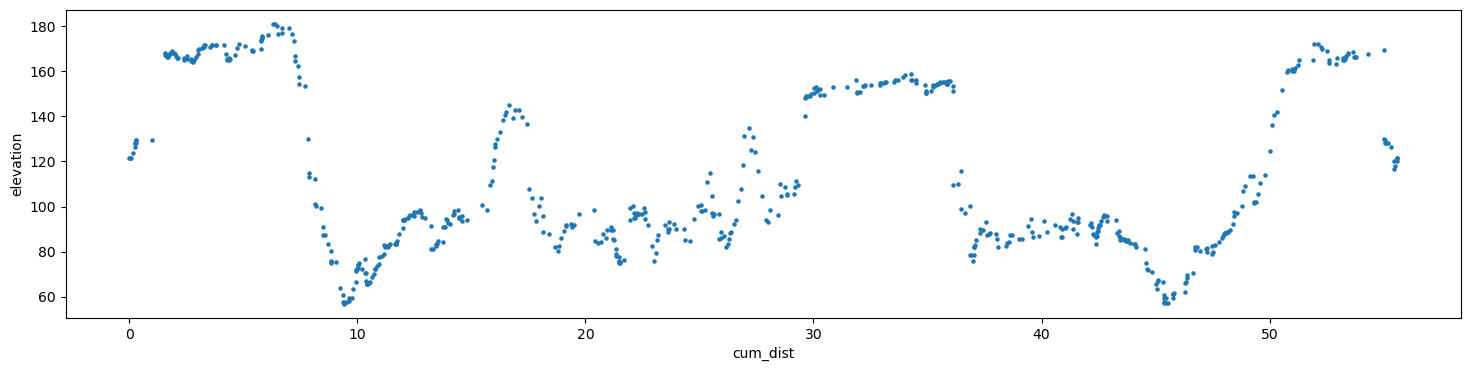

In [ ]:

# plot Profile
best_gdf_nodes_route.plot(kind='scatter', x="cum_dist", y="elevation", marker='.', figsize=(18,4))


# Export as GPX

In [161]:
from datetime import datetime
import geopandas as gpd
from gpx_formatter import TEMPLATE, TRACE_POINT


# best_gdf_nodes_route = convert_paths_to_gdf_with_grades(G, shortest_path)

best_gdf_nodes_route =  gpd.GeoDataFrame(gdf_nodes.loc[shortest_path])

def convert_gdf_to_gpx(gdf, name):
    trace_points = "\n".join([
        TRACE_POINT.format(
            lat=row['y'],
            lon=row['x'],
            elevation=row['elevation'],
            timestamp=datetime.now().isoformat()
        ) for idx, row in gdf.iterrows()
    ])

    gpx_payload = TEMPLATE.format(
        name=name,
        timestamp=datetime.now().isoformat(),
        trace_points=trace_points
    )

    return gpx_payload

# Example usage with your GeoDataFrame
gpx_data = convert_gdf_to_gpx(best_gdf_nodes_route, "My Route")

with open("my_new_route_lab.gpx", "w") as f:
    f.write(gpx_data)


In [ ]:

plt.figure(); plot_objective(opt_res);

# Clear linear relations between x and x+1
plot = plot_convergence(("result", opt_res), yscale="log")